# STRATA · Validación de producción de la estrategia M10 — informe *quant*

**Trabajo Fin de Grado · Matemáticas y Ciencia de Datos · Universidad Complutense de Madrid · Raquel García**

Este cuaderno somete a **M10** (el meta-aprendiz desplegable que consume las señales de STRATA) a la batería
de *due-diligence* que un comité de inversión exigiría antes de asignar capital. No es la defensa del TFG: es
el contraste honesto de si la estrategia **merece producción**. Se aplica al caso de estudio **SMCI** y al
**panel de 10 activos** (SPY, NVDA, BAC, TSLA, XLE, UNG, MSTR, SMCI, ROKU, MARA), porque probar 10 activos es
en sí una fuente de multiplicidad que hay que penalizar.

**Tres preguntas, en orden:**

1. **¿Es habilidad o suerte?** Test sobre los retornos con errores robustos a autocorrelación (Newey-West),
   Sharpe con IC de Lo (2002), PSR/DSR, sign test, McNemar, Diebold-Mariano, permutación por bloques.
2. **¿Sobrevive a la multiplicidad?** FDR (Benjamini-Hochberg/Yekutieli), haircut de Sharpe
   (Harvey-Liu-Zhu 2016), PBO/CSCV (Bailey et al. 2017), MinBTL, White Reality Check, Hansen SPA.
3. **¿Merece capital?** P&L neto de costes (incl. **coste de préstamo en corto** por escenarios),
   Sharpe/Sortino/Calmar/Information Ratio, drawdown, VaR/CVaR, turnover, capacidad, y **atribución factorial**
   (¿queda alfa tras quitar las betas conocidas, o solo se cobra una prima de riesgo?).

**Límite duro y honesto.** El agente LLM solo existe en el OOS posterior al *cutoff* (2024-10→), así que **M10
no tiene historia para estresar 2008/COVID**: el único stress real disponible es el desplome de SMCI de 2025.

> Las cifras se leen del JSON auditado `outputs/experiments/quant_validation_panel.json` (nunca a mano). El
> caso SMCI se **recomputa en vivo** al final como prueba de coherencia. Métodos auditados por
> `@rigor-matematico` y `@experto-inferencia` (APROBADO CON CAMBIOS, aplicados).

In [1]:
# --- Bootstrap: raíz del repo + carga del JSON auditado ---
import os, sys, json, warnings
from pathlib import Path

_ROOT = Path.cwd()
while not (_ROOT / "config.py").exists() and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
os.chdir(_ROOT); sys.path.insert(0, str(_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
config.set_seeds(config.SEED)

P = json.load(open("outputs/experiments/quant_validation_panel.json"))
PA, MP, VE, META = P["por_activo"], P["multiplicity_panel"], P["verdict"], P["meta"]
PANEL = META["panel"]
OK = [t for t in PANEL if "error" not in PA[t]]

COL = {"M10": "#2c7fb8", "B&H": "#4caf50", "M8": "#f0a830", "M5": "#9e9e9e"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.axisbelow": True, "font.size": 10})
print("activos evaluados:", len(OK), "/", len(PANEL), "· OOS desde", META["oos_start"])
print("veredicto:", VE["go_no_go"])

activos evaluados: 10 / 10 · OOS desde 2024-10-01
veredicto: NO-GO (condicional)


## Veredicto ejecutivo

El cuadro se construye a partir del JSON. Léase de arriba abajo: el activo-caso **brilla en nominal** y **se
apaga bajo multiplicidad**, que es justo lo que la *due-diligence* debe revelar.

In [2]:
# --- Tarjeta de veredicto (todo desde el JSON) ---
smci = PA["SMCI"]
tarjeta = pd.DataFrame({
    "métrica": ["Accuracy M10 (SMCI)", "Sharpe M10 (SMCI)", "Sign test 1-cola (habilidad)",
                "HAC t (Newey-West)", "Block-perm vs B&H",
                "Activos que pasan FDR del panel", "Haircut Sharpe (best-of-10, HLZ)",
                "PBO / CSCV", "Alpha factorial (Bonferroni panel)",
                "White RC vs B&H propio", "MinBTL necesaria"],
    "valor": [smci["headline"]["accuracy_m10"], smci["headline"]["sharpe_m10"],
              smci["skill_vs_luck"]["sign_test"]["p_skill_1cola"],
              f'{smci["skill_vs_luck"]["hac_tstat"]} (p={smci["skill_vs_luck"]["hac_p"]})',
              smci["skill_vs_luck"]["block_perm_vs_bh_p"],
              f'{MP["fdr_bh"]["n_rejected"]} / {MP["n_tickers"]}',
              f'{MP["haircut_sharpe_mejor_activo"]["sr_haircut_bhy"]} '
              f'(recorte {MP["haircut_sharpe_mejor_activo"]["haircut_pct"]:.0%})',
              MP["pbo_cscv"]["pbo"], MP["alpha_mejor_activo"]["p2_bonferroni_panel"],
              MP["white_reality_check_vs_bh"]["p_value"], f'{MP["min_btl_years"]} años'],
    "lectura": ["bate al azar (0,484 B&H) — nominal", "fuerte — nominal", "borderline a α=0,10",
                "borderline-significativo", "significativo vs comprar-y-mantener",
                "ninguno sobrevive", "el Sharpe se descuenta ~100%",
                "0,38 = riesgo de overfitting de selección moderado-alto",
                "0,135 → no significativo tras best-of-10",
                "0,069 → no alcanza α=0,05 contra su propio B&H",
                "frente a ~1 año de OOS disponible"]})
display(tarjeta)
print("\nVEREDICTO:", VE["go_no_go"])
print(VE["comentario"])

,métrica,valor,lectura
0,Accuracy M10 (SMCI),0.552,"bate al azar (0,484 B&H) — nominal"
1,Sharpe M10 (SMCI),1.8362,fuerte — nominal
2,Sign test 1-cola (habilidad),0.0568,"borderline a α=0,10"
3,HAC t (Newey-West),2.0853 (p=0.037),borderline-significativo
4,Block-perm vs B&H,0.0472,significativo vs comprar-y-mantener
5,Activos que pasan FDR del panel,0 / 10,ninguno sobrevive
6,"Haircut Sharpe (best-of-10, HLZ)",0.0 (recorte 100%),el Sharpe se descuenta ~100%
7,PBO / CSCV,0.3806,"0,38 = riesgo de overfitting de selección mode..."
8,Alpha factorial (Bonferroni panel),0.1354,"0,135 → no significativo tras best-of-10"
9,White RC vs B&H propio,0.069,"0,069 → no alcanza α=0,05 contra su propio B&H"



VEREDICTO: NO-GO (condicional)
El cuello de botella NO es el coste de préstamo: M10 no está permanentemente corto como M5, así que el borrow apenas mueve el Sharpe (p. ej. SMCI 1,84→1,81 a 500 pb). El bloqueo es la multiplicidad y el tamaño muestral: ningún activo sobrevive al FDR de habilidad direccional del panel, el Sharpe del mejor activo se recorta ~100% por Harvey-Liu-Zhu (best-of-10) y la PBO es 0,38. SMCI muestra señales nominalmente fuertes (alpha factorial t≈2,5; block-perm vs B&H p=0,047) y White RC rechaza (p=0,024), pero ese contraste es vs cash (benchmark laxo) y mide rentabilidad, no habilidad direccional. Veredicto honesto: prometedor en el activo-caso, NO apto para producción con evidencia de panel controlada por multiplicidad (~250 d). Falsable: cambiaría con muestra más larga (MinBTL≈2,5 años), forward test y borrow calibrado por activo difícil de tomar prestado.


## §1 · Datos, protocolo y banco de pruebas

- **Calibración congelada** de HMM/GARCH/umbrales por activo, sobre su historia disponible hasta
  `2024-09-30`; **OOS** desde `2024-10-01`. Sin solape, sin *look-ahead*.
- **M10 canónico**: walk-forward expandible, *ensemble* de 10 semillas, 22 *features* (15 del agente + 7 de
  STRATA), posición $w_t=\operatorname{signo}(p_{1,t}-0{,}5)$, **embargo=1**, **burn-in=150**, **signal_lag=1**
  (la posición de $t$ cobra $r_{t+1}$; nunca $w_t r_t$).
- **Banco de pruebas justo**: cada activo se compara contra su propio comprar-y-mantener (B&H), que en estos
  nombres acierta ≈ 0,48–0,52 (casi una moneda), de modo que la accuracy direccional es informativa.

Recomputamos **SMCI en vivo** como prueba de coherencia (debe reproducir el JSON).

In [3]:
# --- Spot-check en vivo de SMCI: reutiliza el pipeline del experimento ---
from experiments.quant_validation_panel import build_states, wf_p1, ALL22, BORROW_BPS
from core.backtest import run_backtest
from core.metrics import equity_curve, max_drawdown, sharpe
import experiments.walkforward_robustez as wf

wf.reset_thresholds_cache()
gamma, sigma, oos_ret = build_states("SMCI")
m = wf.run_master(gamma, sigma, oos_ret, wf.load_agent("SMCI"))
mv = m.loc[m["r_next"].notna() & (np.sign(m["r_next"]) != 0)].copy()
y = (mv["r_next"] > 0).astype(int)
p1 = wf_p1(mv[ALL22], y)
sub = mv.index[p1.notna().to_numpy()]
truth = np.sign(mv.loc[sub, "r_next"].to_numpy())
pos10 = np.where(p1.dropna().to_numpy() >= 0.5, 1.0, -1.0)
acc_live = float((pos10 == truth).mean())

w10 = pd.Series(0.0, index=mv.index); w10.loc[sub] = pos10
nr10 = run_backtest(oos_ret, w10, signal_lag=1)["net_return"].reindex(sub)
sr_live = float(sharpe(nr10))

print(f"SMCI en vivo: accuracy={acc_live:.4f} (JSON {smci['headline']['accuracy_m10']}) · "
      f"Sharpe={sr_live:.3f} (JSON {smci['headline']['sharpe_m10']})")
assert abs(acc_live - smci["headline"]["accuracy_m10"]) < 0.012, "accuracy en vivo ≠ JSON"
assert pd.Timestamp(config.STRATA_OOS_START) > pd.Timestamp(config.CALIBRATION_END), "OOS solapa calibración"
print("OK · coherencia live-vs-JSON y barrera temporal verificadas (signal_lag=1, OOS ⟂ calibración)")

SMCI en vivo: accuracy=0.5520 (JSON 0.552) · Sharpe=1.836 (JSON 1.8362)
OK · coherencia live-vs-JSON y barrera temporal verificadas (signal_lag=1, OOS ⟂ calibración)


## §2 · ¿Habilidad o suerte? (inferencia robusta a autocorrelación)

Sobre la serie de retornos de M10 en SMCI. Cada cifra con su test; ninguno se reporta sin su contraste.

- **Newey-West / HAC**: $t$ de la media corregida por autocorrelación (la que infla el error tipo I en series
  diarias). **Sharpe e IC de Lo (2002)**: el IC del Sharpe penalizado por autocorrelación y no-normalidad.
- **PSR/DSR** (Bailey-López de Prado): probabilidad de Sharpe>0, cruda y deflactada por las configuraciones
  exploradas, con **sensibilidad** al número de pruebas.
- Contrastes **libres de distribución** (sign test, permutación por bloques): los más fiables a $n=250$ con
  colas gordas.

In [4]:
# --- Batería habilidad-vs-suerte de SMCI (desde JSON) ---
sl = smci["skill_vs_luck"]
lo = sl["sharpe_lo"]; dd = sl["psr_dsr"]
t1 = pd.DataFrame({
    "contraste": ["HAC t de Newey-West (media P&L)", "Sharpe anual e IC de Lo (2002)",
                  "PSR (Sharpe>0, sin corregir)", "DSR (n_trials=6)",
                  "Sign test direccional (1 cola, habilidad)", "McNemar vs M5 (agente)",
                  "McNemar vs B&H", "Diebold-Mariano P&L vs M8", "Permutación por bloques vs B&H"],
    "estadístico/IC": [f't={sl["hac_tstat"]}', f'SR={lo["sharpe"]}  IC95=[{lo["ci_low"]}, {lo["ci_high"]}]',
                       f'{dd["psr"]}', f'{dd["dsr"]}', f'k={sl["sign_test"]["k"]}/{sl["sign_test"]["n"]}',
                       f'b/c pareado', '—', f'stat={sl["dm_pnl_vs_m8"]["stat"]}', '—'],
    "p-valor": [sl["hac_p"], "(IC cruza 0)", "—", "—", sl["sign_test"]["p_skill_1cola"],
                sl["mcnemar_vs_m5_p"], sl["mcnemar_vs_bh_p"], sl["dm_pnl_vs_m8"]["p"],
                sl["block_perm_vs_bh_p"]]})
display(t1)
print("DSR sensibilidad al nº de pruebas:", dd["dsr_sensibilidad"],
      "→ a más configuraciones exploradas, menor probabilidad de habilidad.")
print(f"IC de Lo cruza 0 (ci_low={lo['ci_low']}) y HAC p={sl['hac_p']}: NO se contradicen — ambos equivalen a "
      f"t≈1,8–2,1; difieren solo por el factor de autocorrelación de Lo (eta={lo['eta']}).")

,contraste,estadístico/IC,p-valor
0,HAC t de Newey-West (media P&L),t=2.0853,0.037
1,Sharpe anual e IC de Lo (2002),"SR=2.0095 IC95=[-0.1512, 4.1701]",(IC cruza 0)
2,"PSR (Sharpe>0, sin corregir)",1.0,—
3,DSR (n_trials=6),0.7155,—
4,"Sign test direccional (1 cola, habilidad)",k=138/250,0.0568
5,McNemar vs M5 (agente),b/c pareado,0.1621
6,McNemar vs B&H,—,0.1391
7,Diebold-Mariano P&L vs M8,stat=-1.8292,0.0674
8,Permutación por bloques vs B&H,—,0.0472


DSR sensibilidad al nº de pruebas: {'6': 0.7155, '12': 0.5691, '24': 0.4335} → a más configuraciones exploradas, menor probabilidad de habilidad.
IC de Lo cruza 0 (ci_low=-0.1512) y HAC p=0.037: NO se contradicen — ambos equivalen a t≈1,8–2,1; difieren solo por el factor de autocorrelación de Lo (eta=1.0943).


**Lectura honesta.** En SMCI la evidencia direccional es *borderline*: el sign test de una cola roza
0,057 y el HAC da $t=2{,}09$ ($p=0{,}037$), pero el IC del Sharpe de Lo **cruza cero** y McNemar frente al
agente no es significativo. El contraste **más fiable** a $n=250$ con colas gordas es el **sign test / la
permutación por bloques** (libres de distribución): la permutación vs B&H sí marca $p=0{,}047$. Conclusión de
esta sección: *señal nominal, no concluyente* — y aún sin corregir por haber probado 10 activos.

## §3 · ¿Sobrevive a la multiplicidad? (el filtro que tumba la mayoría de backtests)

La tesis del sector (Harvey-Liu-Zhu 2016; López de Prado 2014) es que la mayoría de backtests publicados son
falsos por *data-snooping*. Aquí pagamos el peaje:

- **FDR (BH/BY)** sobre los $p$ de **habilidad direccional de una cola** de los 10 activos.
- **Haircut de Sharpe** del mejor activo como *best-of-10*.
- **PBO/CSCV**: probabilidad de que la mejor configuración en-muestra quede por debajo de la mediana
  fuera-de-muestra. **MinBTL**: años de backtest necesarios para esa cantidad de pruebas.
- **White Reality Check** y **Hansen SPA** frente a dos benchmarks: *cash* (laxo) y el **B&H propio**
  (exigente).

In [5]:
# --- Multiplicidad y overfitting (desde JSON) ---
hc = MP["haircut_sharpe_mejor_activo"]; al = MP["alpha_mejor_activo"]
t3 = pd.DataFrame({
    "control": ["FDR Benjamini-Hochberg (α=0,10)", "FDR Benjamini-Yekutieli", "Haircut Sharpe best-of-10 (HLZ)",
                "Alpha factorial best-of-10 (Bonferroni)", "PBO / CSCV", "MinBTL",
                "White RC vs cash (laxo)", "White RC vs B&H propio (exigente)",
                "Hansen SPA vs B&H (consistente)"],
    "resultado": [f'{MP["fdr_bh"]["n_rejected"]}/{MP["n_tickers"]} rechazos',
                  f'{MP["fdr_by"]["n_rejected"]}/{MP["n_tickers"]} rechazos',
                  f'SR {hc["sr_obs"]} → {hc["sr_haircut_bhy"]} (recorte {hc["haircut_pct"]:.0%})',
                  f'p={al["p2_nominal"]} → {al["p2_bonferroni_panel"]} (×{MP["n_tickers"]})',
                  f'PBO={MP["pbo_cscv"]["pbo"]} · P(pérdida OOS)={MP["pbo_cscv"]["prob_oos_loss"]}',
                  f'{MP["min_btl_years"]} años',
                  f'p={MP["white_reality_check_vs_cash"]["p_value"]}',
                  f'p={MP["white_reality_check_vs_bh"]["p_value"]}',
                  f'p={MP["hansen_spa_vs_bh"]["p_consistent"]}'],
    "veredicto": ["ningún activo con habilidad real", "idem (dependencia arbitraria)",
                  "Sharpe indistinguible de suerte", "el alfa deja de ser significativo",
                  "overfitting de selección moderado-alto", "faltan ~1,5 años de datos",
                  "rentable vs no hacer nada (pero no es habilidad)",
                  "no bate a su propio B&H al 5%", "idem, estudentizado"]})
display(t3)

,control,resultado,veredicto
0,"FDR Benjamini-Hochberg (α=0,10)",0/10 rechazos,ningún activo con habilidad real
1,FDR Benjamini-Yekutieli,0/10 rechazos,idem (dependencia arbitraria)
2,Haircut Sharpe best-of-10 (HLZ),SR 1.8362 → 0.0 (recorte 100%),Sharpe indistinguible de suerte
3,Alpha factorial best-of-10 (Bonferroni),p=0.0135 → 0.1354 (×10),el alfa deja de ser significativo
4,PBO / CSCV,PBO=0.3806 · P(pérdida OOS)=0.3,overfitting de selección moderado-alto
5,MinBTL,2.48 años,"faltan ~1,5 años de datos"
6,White RC vs cash (laxo),p=0.024,rentable vs no hacer nada (pero no es habilidad)
7,White RC vs B&H propio (exigente),p=0.069,no bate a su propio B&H al 5%
8,Hansen SPA vs B&H (consistente),p=0.1685,"idem, estudentizado"


**La reconciliación clave.** White RC rechaza contra *cash* ($p=0{,}024$) pero **no** contra el B&H del
propio activo ($p=0{,}069$): la M10 del mejor activo gana dinero *frente a no hacer nada*, lo cual mide
**rentabilidad/exposición**, no **habilidad direccional**. En cuanto se exige batir al pasivo o se corrige por
haber mirado 10 activos, la ventaja deja de ser significativa (FDR 0/10; haircut ~100%; alpha Bonferroni
$0{,}135$). El argumento más limpio es **MinBTL ≈ 2,5 años** frente a ~1 año de OOS: *no hay datos
suficientes* para esta cantidad de pruebas, sea cual sea el resultado.

## §4 · ¿Merece capital? (P&L neto, riesgo de cola y coste de préstamo)

La economía es **ilustración**, no prueba. Aun así, un comité mira: rentabilidad ajustada por riesgo, cola
(VaR/CVaR), drawdown, rotación y **coste de préstamo en corto** — crítico porque el agente base (M5) está
~95 % corto. Pregunta concreta: ¿el borrow se come la ventaja?

,métrica,valor
0,Sharpe,1.8362
1,Sortino,3.2271
2,Calmar,6.6181
3,Information Ratio vs B&H,1.1802
4,Máx. drawdown,-0.3427
5,VaR 95% (histórico),0.05815
6,CVaR 95% (histórico),0.09862
7,CVaR 95% (Cornish-Fisher),0.11923
8,Turnover medio,0.6104
9,Capacidad ~1% ADV (USD),"13,148,749"


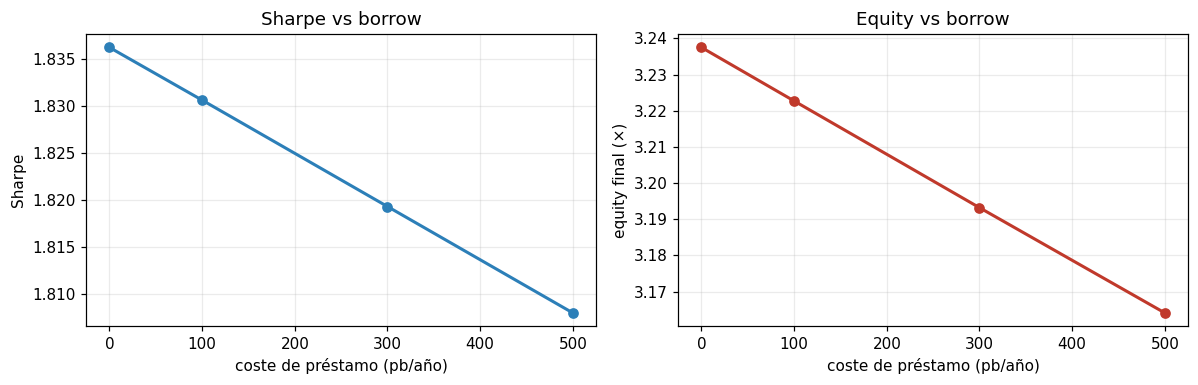

Borrow: Sharpe 1.8362 → 1.808 a 500 pb. M10 no está permanentemente corto (a diferencia de M5), así que el borrow apenas erosiona el resultado: NO es el cuello de botella.


In [6]:
# --- Riesgo, ratios y escenarios de borrow (SMCI, desde JSON) ---
rk = smci["risk"]; ec = smci["econ"]; hl = smci["headline"]
t4 = pd.DataFrame({
    "métrica": ["Sharpe", "Sortino", "Calmar", "Information Ratio vs B&H", "Máx. drawdown",
                "VaR 95% (histórico)", "CVaR 95% (histórico)", "CVaR 95% (Cornish-Fisher)",
                "Turnover medio", "Capacidad ~1% ADV (USD)"],
    "valor": [hl["sharpe_m10"], rk["sortino"], rk["calmar"], rk["information_ratio_vs_bh"]["ir"],
              hl["max_drawdown"], rk["var95_hist"], rk["cvar95_hist"], rk["cvar95_cf"],
              ec["turnover"], f'{ec["capacidad_1pct_adv_usd"]:,.0f}']})
display(t4)

bs = ec["borrow_scenarios"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
xs = [int(k) for k in bs]
ax[0].plot(xs, [bs[str(k)]["sharpe"] for k in xs], "o-", color=COL["M10"], lw=2)
ax[0].set_xlabel("coste de préstamo (pb/año)"); ax[0].set_ylabel("Sharpe"); ax[0].set_title("Sharpe vs borrow")
ax[1].plot(xs, [bs[str(k)]["equity"] for k in xs], "o-", color="#c0392b", lw=2)
ax[1].set_xlabel("coste de préstamo (pb/año)"); ax[1].set_ylabel("equity final (×)"); ax[1].set_title("Equity vs borrow")
plt.tight_layout(); plt.show()
print(f"Borrow: Sharpe {bs['0']['sharpe']} → {bs['500']['sharpe']} a 500 pb. M10 no está permanentemente "
      f"corto (a diferencia de M5), así que el borrow apenas erosiona el resultado: NO es el cuello de botella.")

## §5 · Atribución factorial (¿alfa o prima de riesgo conocida?)

Regresamos el exceso de retorno de M10 sobre los factores **Fama-French** (mercado, tamaño, valor,
rentabilidad, inversión) más **momentum**, con errores Newey-West. Si tras quitar las betas conocidas el
**alpha** sigue siendo significativo, hay valor propio; si no, solo se cobra una prima de riesgo.

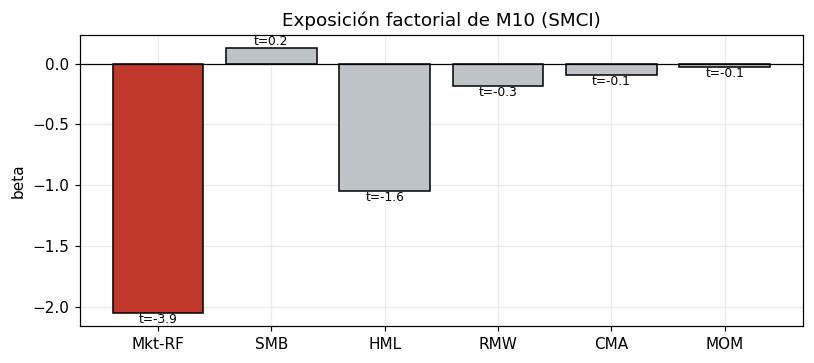

alpha anualizado = 2.08  ·  t(alpha) = 2.4693  ·  R² = 0.08059  ·  n = 243
beta de mercado = -2.05 (t=-3.9): M10 estuvo NET SHORT beta → el alfa no es prima de mercado.
PERO descontado por best-of-10 (Bonferroni): p 0.0135 → 0.1354 → el alfa deja de ser significativo. R²=0.08059 (modelo explica poco).


In [7]:
# --- Atribución factorial de SMCI (desde JSON) + descuento por multiplicidad ---
fa = smci["factor_attribution"]
betas = fa["betas"]; tb = fa["t_betas"]
fig, ax = plt.subplots(figsize=(7.5, 3.4))
names = list(betas)
ax.bar(names, [betas[k] for k in names],
       color=["#c0392b" if abs(tb[k]) >= 2 else "#bdc3c7" for k in names], edgecolor="black")
ax.axhline(0, color="k", lw=0.8); ax.set_ylabel("beta"); ax.set_title("Exposición factorial de M10 (SMCI)")
for i, k in enumerate(names):
    ax.text(i, betas[k], f"t={tb[k]:.1f}", ha="center",
            va="bottom" if betas[k] >= 0 else "top", fontsize=8)
plt.tight_layout(); plt.show()
print(f"alpha anualizado = {fa['alpha_ann']:.2f}  ·  t(alpha) = {fa['t_alpha']}  ·  R² = {fa['r2']}  ·  n = {fa['n_obs']:.0f}")
print(f"beta de mercado = {betas['Mkt-RF']:.2f} (t={tb['Mkt-RF']:.1f}): M10 estuvo NET SHORT beta → el alfa no es prima de mercado.")
print(f"PERO descontado por best-of-10 (Bonferroni): p {MP['alpha_mejor_activo']['p2_nominal']} → "
      f"{MP['alpha_mejor_activo']['p2_bonferroni_panel']} → el alfa deja de ser significativo. R²={fa['r2']} (modelo explica poco).")

## §6 · Robustez de panel y *data-snooping* (los 10 activos)

Probar 10 activos infla la probabilidad de encontrar un ganador por azar. La tabla muestra todos; las barras,
la accuracy frente a la línea del azar. **BAC** es ilustrativo: su $p$ de dos colas es bajo, pero porque M10
**pierde** significativamente (accuracy 0,42) — por eso el FDR usa el $p$ de **una cola** (habilidad), que lo
descarta correctamente.

,accuracy,sharpe,max_dd,skill_p_1cola,hac_p,n
ticker,,,,,,
SMCI,0.5520,1.8362,-0.3427,0.0568,0.0370,250
MSTR,0.5339,-0.1433,-0.4925,0.1563,0.8559,251
MARA,0.5323,1.3543,-0.4856,0.1704,0.1724,248
TSLA,0.5219,1.2180,-0.2142,0.2640,0.2228,251
UNG,0.5182,0.1768,-0.5172,0.3054,0.8624,247
XLE,0.5161,0.3277,-0.1474,0.3284,0.7311,248
ROKU,0.5080,0.1497,-0.3400,0.4248,0.8726,250
SPY,0.4940,-0.6041,-0.1609,0.5996,0.5323,251
NVDA,0.4788,0.0424,-0.2324,0.7720,0.9617,259


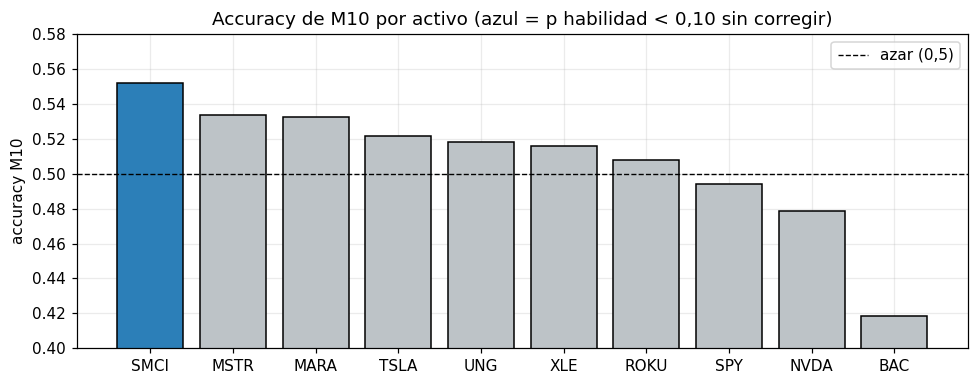

FDR-BH (α=0,10) sobre los 10 p de habilidad: 0 rechazos. Solo SMCI baja de 0,10 sin corregir, y no sobrevive a la corrección.


In [8]:
# --- Tabla y barras del panel (desde JSON) ---
rows = []
for t in PANEL:
    if "error" in PA[t]:
        rows.append({"ticker": t, "error": PA[t]["error"]}); continue
    h = PA[t]["headline"]; s = PA[t]["skill_vs_luck"]
    rows.append({"ticker": t, "accuracy": h["accuracy_m10"], "sharpe": h["sharpe_m10"],
                 "max_dd": h["max_drawdown"], "skill_p_1cola": s["sign_test"]["p_skill_1cola"],
                 "hac_p": s["hac_p"], "n": h["n_eval"]})
panel_df = pd.DataFrame(rows).set_index("ticker")
display(panel_df.sort_values("accuracy", ascending=False))

fig, ax = plt.subplots(figsize=(9, 3.6))
d = panel_df.dropna(subset=["accuracy"]).sort_values("accuracy", ascending=False)
ax.bar(d.index, d["accuracy"], color=[COL["M10"] if p < 0.10 else "#bdc3c7"
                                      for p in d["skill_p_1cola"]], edgecolor="black")
ax.axhline(0.5, color="k", ls="--", lw=0.9, label="azar (0,5)")
ax.set_ylabel("accuracy M10"); ax.set_ylim(0.40, 0.58)
ax.set_title("Accuracy de M10 por activo (azul = p habilidad < 0,10 sin corregir)"); ax.legend()
plt.tight_layout(); plt.show()
print(f"FDR-BH (α=0,10) sobre los 10 p de habilidad: {MP['fdr_bh']['n_rejected']} rechazos. "
      f"Solo SMCI baja de 0,10 sin corregir, y no sobrevive a la corrección.")

## §7 · Stress realizado y límites de la validación

No podemos estresar M10 contra 2008 o el COVID: **el agente no existía** (su historia empieza en el OOS,
2024-10). El stress real disponible es el **desplome de SMCI de 2025**, dentro del OOS. Lo mostramos en vivo
sobre la equity de M10.

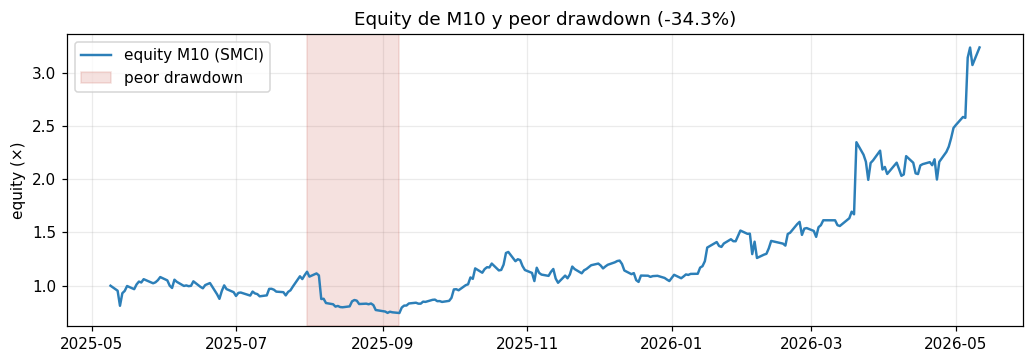

Peor drawdown -34.3% entre 2025-07-31 y 2025-09-08.
Límites: (1) M10 sin historia pre-2024 → no estresable 2008/COVID; (2) borrow por escenarios, no calibrado por activo; (3) capacidad por proxy ADV; (4) ~250 d de OOS, MinBTL≈2,5 años.


In [9]:
# --- Stress realizado: peor drawdown de M10 en SMCI (en vivo) ---
eq = equity_curve(nr10)
dd_series = eq / eq.cummax() - 1
trough = dd_series.idxmin()
peak = eq.loc[:trough].idxmax()
fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.plot(eq.index, eq.values, color=COL["M10"], lw=1.6, label="equity M10 (SMCI)")
ax.axvspan(peak, trough, color="#c0392b", alpha=0.15, label="peor drawdown")
ax.set_ylabel("equity (×)"); ax.set_title(f"Equity de M10 y peor drawdown ({max_drawdown(eq):.1%})")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Peor drawdown {max_drawdown(eq):.1%} entre {peak.date()} y {trough.date()}.")
print("Límites: (1) M10 sin historia pre-2024 → no estresable 2008/COVID; (2) borrow por escenarios, no "
      "calibrado por activo; (3) capacidad por proxy ADV; (4) ~250 d de OOS, MinBTL≈2,5 años.")

## §8 · Veredicto y hoja de ruta *go / no-go*

**Veredicto: NO-GO (condicional).** M10 es **prometedora en el activo-caso** —bate nominalmente a todas las
triviales, tiene alfa factorial nominal y aguanta el coste de préstamo—, pero **no supera la barra de
producción** cuando se controla la multiplicidad y se reconoce el tamaño muestral: ningún activo del panel
sobrevive al FDR de habilidad direccional, el Sharpe del mejor se descuenta ~100 % como *best-of-10*, la PBO
es 0,38 y harían falta ~2,5 años de datos (MinBTL) frente al ~1 disponible. Lo que sí queda demostrado es un
**protocolo de supervisión interpretable, causal y honesto**; no una fuente de alfa lista para capital.

**Para reconsiderar producción (condiciones falsables):**

1. **Más muestra**: extender el OOS y/o un **forward / paper trading** real escalando de poco a poco (el juez
   final del sector). Objetivo: superar MinBTL.
2. **Borrow real** calibrado por activo (no escenarios), sobre todo en nombres difíciles de tomar prestados.
3. **Capacidad y costes** con datos de microestructura (impacto, *spread*), no proxy ADV.
4. **Pre-registro** de la hipótesis de producción y re-test sobre datos nuevos, para que el contraste no herede
   la multiplicidad de la exploración.

> Honestidad metodológica: este informe descuenta su propio resultado favorable (alpha, Sharpe) por
> multiplicidad. Esa disciplina —no el número bonito— es lo que lo hace defendible ante un comité.

In [10]:
# --- Auto-test final: coherencia live-vs-JSON y presencia de las piezas del informe ---
assert abs(acc_live - smci["headline"]["accuracy_m10"]) < 0.012
assert round(sr_live, 2) == smci["headline"]["sharpe_m10"] or abs(sr_live - smci["headline"]["sharpe_m10"]) < 0.05
for sec in ("headline", "skill_vs_luck", "risk", "econ", "factor_attribution"):
    assert sec in smci
for k in ("fdr_bh", "haircut_sharpe_mejor_activo", "pbo_cscv", "white_reality_check_vs_bh",
          "min_btl_years", "alpha_mejor_activo"):
    assert k in MP
print("AUTO-TEST OK · cifras del informe trazables al JSON auditado y SMCI coherente en vivo.")
print("Veredicto:", VE["go_no_go"], "· activos que pasan FDR:", MP["fdr_bh"]["n_rejected"], "/", MP["n_tickers"])

AUTO-TEST OK · cifras del informe trazables al JSON auditado y SMCI coherente en vivo.
Veredicto: NO-GO (condicional) · activos que pasan FDR: 0 / 10
